# Urban Public Service Reviews: Text Study
A full text analysis pipeline for Google Maps reviews from public service locations in Yogyakarta

## Part 0: Current Issue and Related Work
I use the article [Crowdsourcing public attitudes toward local services through the lens of Google Maps reviews: An urban density-based perspective](https://arxiv.org/abs/2404.13156) to frame the problem. The paper treats public service evaluation as a text classification task using large-scale Google Maps reviews.

**How I adapt the idea**
The paper links review content to urban density and spatial context. In this notebook, I keep the same review-based sentiment idea but use a simpler pipeline (preprocessing, TF-IDF, Word2Vec, and basic classifiers) to build a clear baseline for the assignment. This can be extended later with spatial features.

## Part 1: Data Collection Summary
load the collected dataset and check its size, columns, and a small sample.

### Data Collection Assets
- Destination list used for scraping: [public_service_destination.csv](public_service_destination.csv)
- Raw scraped reviews (before cleaning): [yogyakarta_public_service_reviews.csv](yogyakarta_public_service_reviews.csv)
- Scraping script: [scraping/google_reviews_scraper.py](scraping/google_reviews_scraper.py)

The scraper visits each destination from the list, opens Google Maps reviews, and collects up to a fixed number of reviews per location. The raw CSV stores destination info, reviewer details, star ratings, timestamps, and review text.

### Dataset Description
The dataset consists of Google Maps reviews collected from public service locations in Yogyakarta, Indonesia. The data was collected using a custom scraping script that visited predefined destinations such as hospitals, transportation hubs, government offices, and public parks.

#### Dataset Characteristics
- Source: Google Maps reviews
- Number of reviews: 1,445
- Number of destinations: 20
- Categories:
  - Hospitals
  - Transportation
  - Government Offices
  - Public Parks

#### Main Features
| Column | Description |
|---|---|
| destination | Name of the location |
| category | Type of public service |
| user_url | Reviewer profile URL |
| username | Reviewer display name |
| stars | User star rating |
| time | Review timestamp |
| text | Review text |

In [32]:
# Load the destination list used for scraping
import pandas as pd
destinations = pd.read_csv('public_service_destination.csv')
destinations

,category,name,search_query
0,Hospital,Dr. Sardjito General Hospital,Dr. Sardjito General Hospital Yogyakarta
1,Hospital,Panti Rapih Hospital,Panti Rapih Hospital Yogyakarta
2,Hospital,JIH Hospital,JIH Hospital Yogyakarta
3,Hospital,Siloam Hospitals Yogyakarta,Siloam Hospitals Yogyakarta
4,Hospital,Bethesda Hospital Yogyakarta,Bethesda Hospital Yogyakarta
5,Hospital,Rumah Sakit Umum Daerah (RSUD) Kota Yogyakarta,RSUD Kota Yogyakarta
6,Public Health Center,Umbulharjo Public Health Center 1,Umbulharjo Public Health Center 1 Yogyakarta
7,Public Health Center,Puskesmas Piyungan,Puskesmas Piyungan Yogyakarta
8,Transportation,Terminal Giwangan Yogyakarta,Terminal Giwangan Yogyakarta
9,Transportation,Terminal Ngabean,Terminal Ngabean Yogyakarta


In [27]:
# Load the raw reviews dataset
import pandas as pd
import re
from pathlib import Path

DATA_FILE = Path('yogyakarta_public_service_reviews.csv')
df = pd.read_csv(DATA_FILE)
df.head()

,destination,category,user_url,username,stars,time,text
0,Dr. Sardjito General Hospital,Hospital,https://www.google.com/maps/contrib/1164352599...,Efan Putra,5,5 months ago,One of the Best Government Hospital in Indones...
1,Dr. Sardjito General Hospital,Hospital,https://www.google.com/maps/contrib/1065948193...,Shifa.,1,Edited 9 months ago,"Honest review here, this is my second visit wi..."
2,Dr. Sardjito General Hospital,Hospital,https://www.google.com/maps/contrib/1129959024...,Fendy A. Fahreza,5,5 months ago,Rwlatively Good healthcare services despite j...
3,Dr. Sardjito General Hospital,Hospital,https://www.google.com/maps/contrib/1107813050...,bib Gnpc,1,a year ago,Was there for rujukan treatment on 22 Jan 25 f...
4,Dr. Sardjito General Hospital,Hospital,https://www.google.com/maps/contrib/1162285274...,DITALIA EKAWAHYUNI 240301129,5,11 months ago,During my three-week psychiatric nursing rotat...


In [43]:
# Inspect dataset size, types, and basic descriptive stats
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.info())
display(df.describe(include='all').transpose().head(12))

Shape: 1,445 rows x 8 columns
<class 'pandas.DataFrame'>
RangeIndex: 1445 entries, 0 to 1444
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   destination      1445 non-null   str  
 1   category         1445 non-null   str  
 2   user_url         1445 non-null   str  
 3   username         1445 non-null   str  
 4   stars            1445 non-null   int64
 5   time             1445 non-null   str  
 6   text             1403 non-null   str  
 7   raw_text_length  1445 non-null   int64
dtypes: int64(2), str(6)
memory usage: 90.4 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
destination,1445,19,Dr. Sardjito General Hospital,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1445,5,Hospital,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_url,1445,1406,https://www.google.com/maps/contrib/1165116750...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
username,1445,1406,Waqqas Hanafi,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stars,1445.0,NaN,NaN,NaN,4.301038,1.248836,1.0,4.0,5.0,5.0,5.0
time,1445,41,a year ago,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,1403,1356,Ok,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
raw_text_length,1445.0,NaN,NaN,NaN,25.274048,29.99069,0.0,6.0,17.0,37.0,436.0


,destination,category,user_url,username,stars,time,text,raw_text_length
0,Dr. Sardjito General Hospital,Hospital,https://www.google.com/maps/contrib/1164352599...,Efan Putra,5,5 months ago,One of the Best Government Hospital in Indones...,24
1,Dr. Sardjito General Hospital,Hospital,https://www.google.com/maps/contrib/1065948193...,Shifa.,1,Edited 9 months ago,"Honest review here, this is my second visit wi...",189
2,Dr. Sardjito General Hospital,Hospital,https://www.google.com/maps/contrib/1129959024...,Fendy A. Fahreza,5,5 months ago,Rwlatively Good healthcare services despite j...,11
3,Dr. Sardjito General Hospital,Hospital,https://www.google.com/maps/contrib/1107813050...,bib Gnpc,1,a year ago,Was there for rujukan treatment on 22 Jan 25 f...,80
4,Dr. Sardjito General Hospital,Hospital,https://www.google.com/maps/contrib/1162285274...,DITALIA EKAWAHYUNI 240301129,5,11 months ago,During my three-week psychiatric nursing rotat...,148


Shape: 1,445 rows x 8 columns


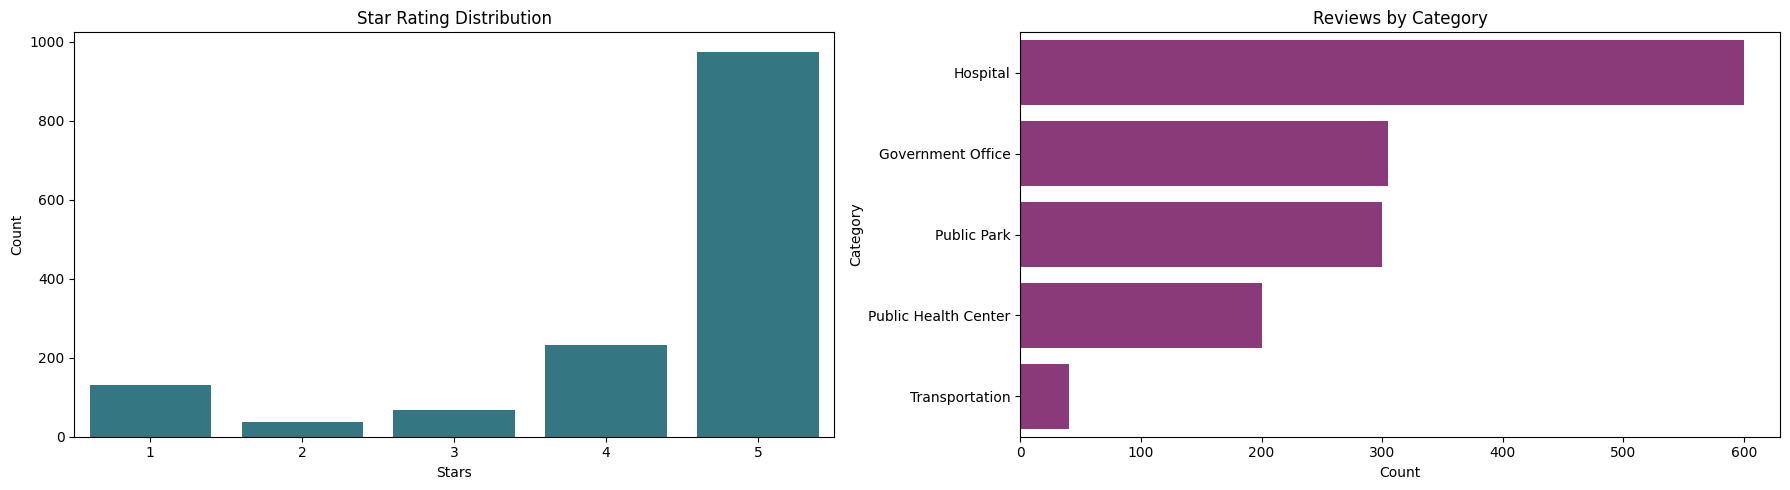

In [45]:
import seaborn as sns

import matplotlib.pyplot as plt

# Basic overview of the raw data
display(df.head())
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.countplot(data=df, x="stars", ax=axes[0], color=sns.color_palette("viridis")[2])
axes[0].set_title("Star Rating Distribution")
axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Count")

sns.countplot(data=df, y="category", order=df["category"].value_counts().index, ax=axes[1], color=sns.color_palette("magma")[2])
axes[1].set_title("Reviews by Category")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Category")

plt.tight_layout()
plt.show()

## Part 2: Preprocessing
I apply lowercasing, punctuation removal, tokenization, stopword removal (Indonesian + English), and stemming (Sastrawi for Indonesian, Porter for English). I also show examples before and after preprocessing.

In [46]:
# Text preprocessing utilities for mixed English/Indonesian reviews
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Ensure NLTK data is available
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

# Combined stopword list (Indonesian + English)
INDONESIAN_STOP_WORDS = set([
    'yang','dan','di','ke','dari','ini','itu','dengan','untuk','pada',
    'adalah','sebagai','dalam','tidak','akan','tetapi','juga','atau',
    'karena','ada','bisa','sudah','saya','kami','kita','mereka','anda',
    'dia','ia','beliau','kamu','kalian','nya','ku','mu',
    'oleh','tentang','seperti','ketika','setelah','sebelum','jika','bila',
    'maka','sehingga','agar','supaya','namun','walau','walaupun','meski',
    'meskipun','sedang','sambil','bahwa','daripada','demi','hingga',
    'sampai','selama','sejak','antara','terhadap','mengenai','sekitar',
    'satu','dua','tiga','empat','lima','enam','tujuh','delapan',
    'sembilan','sepuluh','banyak','sedikit','beberapa','semua','setiap',
    'para','sang','si','tersebut','begitu','demikian',
    'sangat','amat','sekali','paling','lebih','kurang','cukup','agak',
    'hampir','selalu','sering','kadang','jarang','bukan','belum',
    'telah','pernah','masih','lagi','hanya','saja','pun',
    'bahkan','justru','malah','terlalu','begini','begitu',
    'dapat','harus','perlu','boleh','mau','ingin','hendak',
    'tengah','mulai','terus','tetap',
    'apa','siapa','mana','kapan','dimana','kemana','bagaimana','mengapa',
    'kenapa','berapa',
    'yg','dgn','utk','krn','klo','kalo','gak','ga','nggak','ngga',
    'udah','udh','blm','tp','tpi','tapi','jd','jadi','jg','sm','sama',
    'bgt','banget','aja','doang','dong','deh','sih','nih',
    'tuh','lho','loh','kok','kan','ya','yaa','gitu','gini','gimana',
    'gmn','emang','emg','bkn','kyk','kayak','kaya','dlm','dr','pd',
    'sy','ak','aku','gw','gue','lo','lu','bs','hrs','org','orang',
    'yah','wkwk','wkwkwk','haha','hehe','hihi','huhu',
    'hari','minggu','bulan','tahun','jam','menit','detik','pagi',
    'siang','sore','malam','kemarin','besok','lusa','nanti','tadi',
    'sekarang','dulu','lalu',
    'sini','situ','sana','tempat','disini','disitu','disana','kesini',
    'kesitu','kesana',
    'hal','cara','waktu','kali','lain','sendiri','bersama',
    'per','tiap','sebuah','suatu','salah','berbagai','macam','jenis',
    'oh','ah','eh','uh','ih','aduh','astaga','wow','yay','yeay'
 ])
ENGLISH_STOP_WORDS = set(stopwords.words('english'))
ALL_STOP_WORDS = INDONESIAN_STOP_WORDS.union(ENGLISH_STOP_WORDS)

# Initialize stemmers for Indonesian and English
STEMMER_ID = StemmerFactory().create_stemmer()
STEMMER_EN = PorterStemmer()

def clean_text(text):
    # Lowercase and remove URLs, emails, numbers, and punctuation
    if pd.isna(text) or not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = ' '.join(text.split())
    return text

def tokenize_text(text):
    # Split cleaned text into alphanumeric tokens
    return re.findall(r'[A-Za-z0-9]+', text.lower())

def remove_stopwords(tokens):
    # Filter stopwords from tokens
    return [t for t in tokens if t not in ALL_STOP_WORDS]

def stem_tokens(tokens):
    # Apply Indonesian stemmer first, then English stemmer when needed
    stemmed = []
    for t in tokens:
        s = STEMMER_ID.stem(t)
        if s == t and t.isascii() and re.fullmatch(r'[a-z]+', t):
            s = STEMMER_EN.stem(t)
        stemmed.append(s)
    return stemmed

def preprocess_text(text):
    # Full pipeline: clean -> tokenize -> stopwords -> stem
    cleaned = clean_text(text)
    tokens = tokenize_text(cleaned)
    tokens = remove_stopwords(tokens)
    tokens = stem_tokens(tokens)
    return ' '.join(tokens)

# Apply preprocessing and compare before/after samples
df['cleaned_text'] = df['text'].apply(preprocess_text)
df[['text', 'cleaned_text']].head(5)

,text,cleaned_text
0,One of the Best Government Hospital in Indones...,one best govern hospit indonesia advic maintai...
1,"Honest review here, this is my second visit wi...",honest review second visit within week surpris...
2,Rwlatively Good healthcare services despite j...,rwlativ good healthcar servic despit pack visi...
3,Was there for rujukan treatment on 22 Jan 25 f...,rujuk treatment jan child encount extrem rude ...
4,During my three-week psychiatric nursing rotat...,three week psychiatr nurs rotat teratai ward s...


## Part 3: Feature Engineering
Build two representations: TF-IDF and Word2Vec.

**TF-IDF (Term Frequency-Inverse Document Frequency)** weights terms by how often they appear in a document while down-weighting terms that are common across the corpus. In this notebook, the TF-IDF vectorizer is defined here and fit once later in the classification step so the same pipeline is used consistently.

**Word2Vec** learns dense vector embeddings that capture semantic relationships between words based on their context. I train Word2Vec on the cleaned reviews and average the word vectors to represent each review.

In the classification section, TF-IDF is used as the baseline feature set because it is strong, interpretable, and well suited to small-to-medium sentiment datasets. Word2Vec is included to demonstrate semantic feature representation.

In [48]:
# Define a reusable TF-IDF vectorizer; it will be fit once in the classification step
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [21]:
# Train Word2Vec on tokenized reviews and average vectors per review
from gensim.models import Word2Vec
import numpy as np

tokenized = df['cleaned_text'].str.split()
w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=2, workers=2)

def average_word2vec(tokens, model, size=100):
    # Average word vectors to represent a review
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if not vectors:
        return np.zeros(size)
    return np.mean(vectors, axis=0)

X_w2v = np.vstack([average_word2vec(t, w2v_model, 100) for t in tokenized])
X_w2v.shape

## Part 4: Exploratory Data Analysis and Visualization
I visualize word frequencies, text length distribution, and separate word clouds for positive and negative reviews to summarize common themes in the corpus.

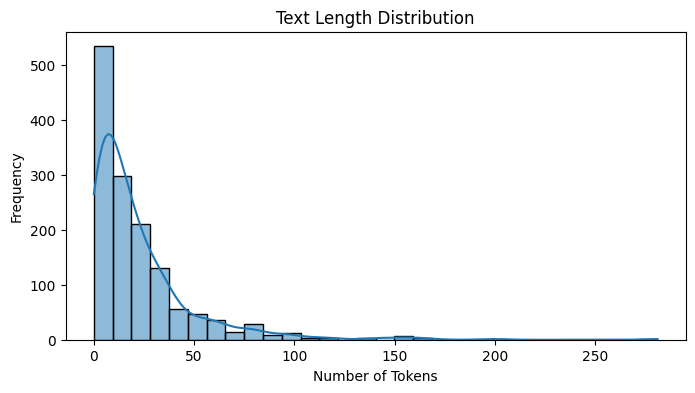

In [16]:
# Plot text length distribution
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

df['text_length'] = df['cleaned_text'].str.split().apply(len)

plt.figure(figsize=(8, 4))
sns.histplot(df['text_length'], bins=30, kde=True)
plt.title('Text Length Distribution')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()

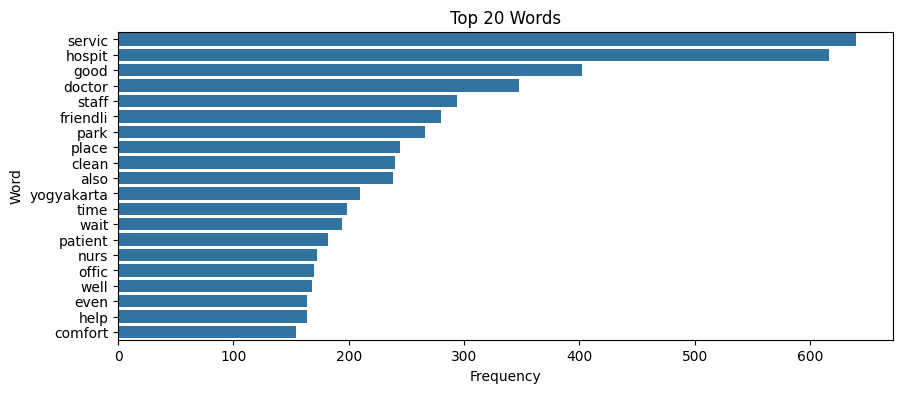

In [10]:
# Plot top word frequencies
all_tokens = [tok for row in tokenized for tok in row]
top_words = Counter(all_tokens).most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 4))
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 20 Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

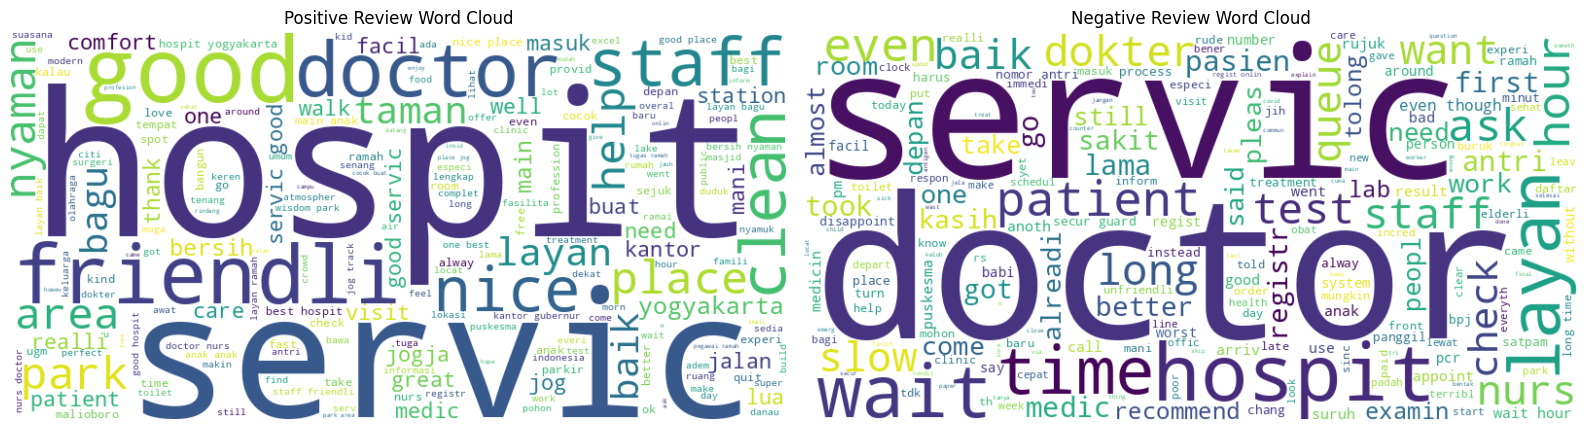

In [49]:
# Generate separate word clouds for positive and negative reviews
positive_text = ' '.join(df.loc[df['stars'] >= 4, 'cleaned_text'].dropna())
negative_text = ' '.join(df.loc[df['stars'] <= 2, 'cleaned_text'].dropna())

positive_text = positive_text if positive_text.strip() else 'positive reviews'
negative_text = negative_text if negative_text.strip() else 'negative reviews'

positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(positive_wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Review Word Cloud')

axes[1].imshow(negative_wordcloud, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Review Word Cloud')

plt.tight_layout()
plt.show()

**Part 4 Summary**
Visualized text length distribution, top word frequencies, and a word cloud to identify dominant themes in the reviews. Use these plots to discuss common concerns.

## Part 5: Text Classification
I create binary sentiment labels from star ratings. Neutral reviews (3-star ratings) are excluded to simplify the task into binary sentiment classification. This creates clearer sentiment boundaries between positive and negative classes and reduces ambiguity during training.

I train classifiers on TF-IDF features and report accuracy, precision, recall, F1 score, a classification report, and a confusion matrix visualization.

Word2Vec embeddings are generated separately to demonstrate semantic feature representation, while TF-IDF is used for the baseline classification models because it is a strong and interpretable choice for this dataset.

,accuracy,precision,recall,f1
LogisticRegression,0.880435,0.880000,1.0,0.936170
MultinomialNB,0.876812,0.876812,1.0,0.934363


Logistic Regression Classification Report
              precision    recall  f1-score   support

    Negative       1.00      0.03      0.06        34
    Positive       0.88      1.00      0.94       242

    accuracy                           0.88       276
   macro avg       0.94      0.51      0.50       276
weighted avg       0.89      0.88      0.83       276



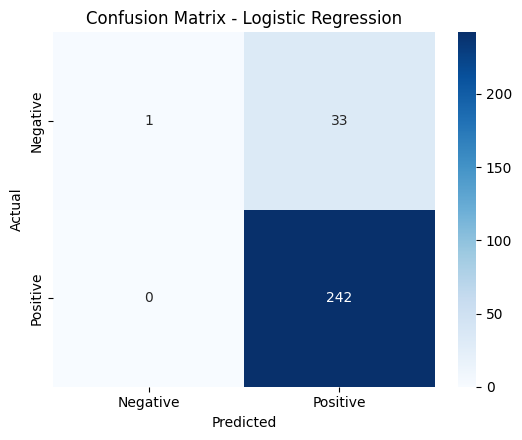

In [51]:
# Train baseline classifiers with TF-IDF features
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def make_binary_label(stars):
    # Convert star ratings into binary sentiment labels
    if stars <= 2:
        return 0
    if stars >= 4:
        return 1
    return None

df['sentiment'] = df['stars'].apply(make_binary_label)
df_cls = df.dropna(subset=['sentiment']).copy()
y = df_cls['sentiment'].astype(int)

# Fit TF-IDF once on the classification subset
X = tfidf.fit_transform(df_cls['cleaned_text'])

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def evaluate(model, X_tr, X_te, y_tr, y_te, return_preds=False):
    # Fit model and compute metrics
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    metrics = {
        'accuracy': accuracy_score(y_te, preds),
        'precision': precision_score(y_te, preds, zero_division=0),
        'recall': recall_score(y_te, preds, zero_division=0),
        'f1': f1_score(y_te, preds, zero_division=0),
    }
    if return_preds:
        return metrics, preds
    return metrics

logistic_metrics, logistic_preds = evaluate(
    LogisticRegression(max_iter=1000), X_train, X_test, y_train, y_test, return_preds=True
 )
nb_metrics = evaluate(MultinomialNB(), X_train, X_test, y_train, y_test)

results = {
    'LogisticRegression': logistic_metrics,
    'MultinomialNB': nb_metrics
}

display(pd.DataFrame(results).transpose())

print('Logistic Regression Classification Report')
print(classification_report(
    y_test, logistic_preds, target_names=['Negative', 'Positive'], zero_division=0
))

cm = confusion_matrix(y_test, logistic_preds)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
 )
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Part 6: Theory Questions

### Question 1: Text Classification vs. Text Clustering
Text classification is a supervised learning task where a model trained on labeled data assigns predefined categories to new documents. Text clustering is an unsupervised learning task where the algorithm autonomously discovers natural groupings in unlabeled data based on document similarity. The core distinction is that classification requires known labels beforehand, while clustering discovers structure without any labels.

Reference: Aggarwal, C. C., & Zhai, C. (2012). *Mining Text Data*. Springer. Chapter 6, Section 6.1, p. 163. 

### Question 2: When Is Text Clustering Applied?
Text clustering is useful when: (1) no labeled data exists, making supervised classification infeasible; (2) exploratory analysis is needed to discover unknown themes in a corpus; or (3) topics evolve dynamically, such as in news streams or social media. Common use cases include news article grouping, customer feedback analysis, scientific literature organization, and social media trend detection.

Reference: Aggarwal, C. C., & Zhai, C. (2012). *Mining Text Data*. Springer. Chapter 4, p. 77–78.

### Question 3: Determining the Optimal k in K-Means
Method 1 - Elbow Method
Run K-means for a range of k values and plot the Within-Cluster Sum of Squares (WCSS) for each. The optimal k is the elbow point where the curve's rate of decrease sharply flattens, beyond which adding more clusters yields diminishing returns.

Method 2 - Silhouette Method
For each point $i$, compute:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$

where $a(i)$ is the mean intra-cluster distance and $b(i)$ is the mean distance to the nearest neighboring cluster. Scores range from -1 to +1, with higher values indicating better-defined clusters. The $k$ that maximizes the mean silhouette score is selected as optimal. This method is more rigorous than the elbow method because it measures both cohesion and separation.

Reference (Silhouette): Rousseeuw, P. J. (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis*. Journal of Computational and Applied Mathematics, 20, 53–65. Section 2, p. 55–57. 

Reference (Elbow): Ketchen, D. J., & Shook, C. L. (1996). *The Application of Cluster Analysis in Strategic Management Research*. Strategic Management Journal, 17(6), 441–458. p. 448–449.

## Limitations
This study has several limitations:
- Reviews were collected only from Google Maps.
- Binary sentiment labels were inferred from star ratings.
- The dataset may contain noisy, repetitive, or sarcastic reviews.
- Spatial and temporal analysis were not included.
- Classical machine learning models were prioritized over transformer-based approaches for assignment simplicity.